# 📊 Pandas vs. Polars for Data Engineering in AI

---

## 1. Overview

In AI engineering, data preprocessing and feature engineering occupy a significant portion of the workflow. Traditional pipelines have relied heavily on **Pandas**, the industry standard for table manipulation in Python. However, as dataset sizes have grown—especially when processing millions of text prompts, token logs, or clickstreams—Pandas can become a major bottleneck due to its single-threaded execution and high memory overhead.

**Polars** is a modern, high-performance DataFrame library written in Rust and built on top of the **Apache Arrow** memory model. It utilizes multi-threaded execution, query optimization, and lazy evaluation to process datasets up to **10-100x faster** than Pandas, using a fraction of the memory.

This notebook provides a side-by-side comparison of Pandas and Polars. It covers core DataFrame operations, lazy evaluation patterns, and a performance benchmark on a dataset of 1,000,000 records. Understanding both libraries is a crucial skill for modern AI engineers building high-throughput data and model training pipelines.

## 2. Learning Objectives

By the end of this notebook, you will be able to:

- Load and inspect structured datasets using both Pandas and Polars.
- Perform core data wrangling operations (filtering, selecting, grouping, and joining) using idiomatic syntax in both libraries.
- Explain the structural differences between Pandas (single-threaded, eager, NumPy-backed) and Polars (multi-threaded, lazy, Arrow-backed).
- Write and optimize Polars **LazyFrames** using query optimization features (predicate and projection pushdowns).
- Build reproducible data-cleaning pipelines handling missing values and string parsing.
- Run and plot a performance benchmark comparing Pandas and Polars execution times.

## 3. Imports

We will check dependency versions to ensure compatibility. Polars has evolved significantly, so we target modern versions (0.20+ or 1.x).

In [1]:
import time
from typing import Dict, Any, List

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Polars version: {pl.__version__}")

NumPy version: 2.0.2
Pandas version: 2.2.2
Polars version: 1.35.2


## 4. Configuration

We set up random seeds for synthetic data generation and set formatting rules for our plots and display outputs.

In [2]:
# Reproducibility seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Pandas display options
pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 1000)

# Matplotlib configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

## 5. Theory & Key Concepts

### 5.1 Pandas Architecture: Single-Threaded & Eager

Pandas was designed in an era where data fit comfortably in memory and CPUs were mostly single-threaded. Its backend is built on **NumPy arrays**, which represent data as contiguous blocks of memory. While NumPy is highly optimized for vector operations in C, it has structural limitations when applied to DataFrames:

1. **Single-Threaded Execution**: Almost all Pandas operations run on a single CPU core. If you have a 16-core machine, 15 cores remain idle during a large `groupby` or `join` operation.
2. **Memory Overhead**: Pandas typically requires **2x to 5x** the raw dataset size in RAM to perform operations because it frequently copies data instead of operating in-place.
3. **Eager Evaluation**: Every operation is executed immediately. If you load a 10 GB CSV, filter out 99% of the rows, and select 2 columns, Pandas eagerly loads the entire 10 GB file into RAM first before dropping the unused rows and columns.

### 5.2 Polars Architecture: Multi-Threaded, Lazy, and Arrow-Backed

Polars represents a complete paradigm shift, built from scratch in Rust with a focus on modern hardware utilization:

1. **Apache Arrow Memory Model**: Apache Arrow is a cross-language development platform for in-memory columnar data. By aligning memory layout vertically (columns instead of rows), Arrow makes vectorization (SIMD) and zero-copy data sharing between languages (e.g., Rust and Python) trivial.
2. **Parallel Execution Engine**: Polars splits DataFrame operations across all available CPU cores using Rust's work-stealing threading framework (`Rayon`). Common operations like aggregations and joins are parallelized out of the box.
3. **Lazy Evaluation (LazyFrames)**: Instead of executing operations step-by-step, Polars builds a **Logical Plan** (Directed Acyclic Graph or DAG). Before executing the plan via `.collect()`, Polars runs a query optimizer that restructures the query to run as efficiently as possible.

$$\text{Logical Plan Optimization} = \text{Predicate Pushdown} + \text{Projection Pushdown}$$

### 5.3 Query Optimization Techniques

*   **Predicate Pushdown (Filter Pushdown)**: Filters are moved as close to the data source as possible. If you load a database table and apply a filter, Polars pushes the filter into the file scanner (e.g., Parquet reader), meaning it only reads the rows matching the filter from disk.
*   **Projection Pushdown (Column Selection)**: Columns that are not needed in the final output are dropped at the scanner level. If a dataset has 100 columns and you select 2, Polars only parses those 2 columns from disk.

The following diagram visualizes Eager vs. Lazy execution flows:

```
EAGER (Pandas):
[Read 100 Cols, 1M Rows] ---> [Memory: 1M Rows x 100 Cols] ---> [Filter Rows] ---> [Select 2 Cols] ---> [Final Result]
                                                                                                (High RAM overhead)

LAZY (Polars):
[Read Query Plan] ---> [Optimizer: Push Filter + Select to Reader] ---> [Read 2 Cols, Match Rows] ---> [Final Result]
                                                                                                (Minimal RAM overhead)
```

## 6. Implementation: Data Wrangling Comparison

To ground these concepts, we will generate a synthetic dataset representing **AI Model Prompt Logs**. We will then write equivalent Pandas and Polars operations side-by-side.

### 6.1 Creating the Synthetic Prompt Logs

Each log entry contains:
- `log_id`: Unique identifier
- `model_name`: The LLM used (`llama-3-8b`, `phi-4`, `gemini-1.5`)
- `tokens_prompt`: Number of tokens in input prompt
- `tokens_completion`: Number of tokens in output response
- `response_time_ms`: Processing latency in milliseconds
- `user_region`: Geographic region of caller
- `has_error`: Boolean error flag

In [3]:
def generate_prompt_logs(n_records: int) -> Dict[str, Any]:
    """Generates a dictionary of synthetic LLM API prompt logs."""
    rng = np.random.default_rng(RANDOM_SEED)
    
    models = ["llama-3-8b", "phi-4", "gemini-1.5-flash", "gpt-4o-mini"]
    regions = ["us-east", "us-west", "eu-central", "ap-northeast", None]  # Include missing regions
    
    return {
        "log_id": [f"log_{i:07d}" for i in range(n_records)],
        "model_name": rng.choice(models, size=n_records).tolist(),
        "tokens_prompt": rng.integers(10, 2000, size=n_records).tolist(),
        "tokens_completion": rng.integers(5, 1000, size=n_records).tolist(),
        "response_time_ms": rng.normal(loc=450, scale=150, size=n_records).astype(int).clip(50, 3000).tolist(),
        "user_region": rng.choice(regions, size=n_records).tolist(),
        "has_error": rng.choice([True, False], p=[0.02, 0.98], size=n_records).tolist(),
    }

# Create data with 100,000 records for general comparison
raw_data = generate_prompt_logs(100_000)

### 6.2 Loading DataFrames

Let's instantiate both a Pandas DataFrame and a Polars DataFrame.

In [4]:
# Pandas load
df_pd = pd.DataFrame(raw_data)

# Polars load
df_pl = pl.DataFrame(raw_data)

print("Pandas Head:")
display(df_pd.head(3))

print("\nPolars Head:")
print(df_pl.head(3))

Pandas Head:


,log_id,model_name,tokens_prompt,tokens_completion,response_time_ms,user_region,has_error
0,log_0000000,llama-3-8b,1473,995,640,eu-central,False
1,log_0000001,gpt-4o-mini,1765,939,464,us-west,False
2,log_0000002,gemini-1.5-flash,1147,963,447,us-west,False



Polars Head:
shape: (3, 7)
┌─────────────┬──────────────┬──────────────┬──────────────┬─────────────┬─────────────┬───────────┐
│ log_id      ┆ model_name   ┆ tokens_promp ┆ tokens_compl ┆ response_ti ┆ user_region ┆ has_error │
│ ---         ┆ ---          ┆ t            ┆ etion        ┆ me_ms       ┆ ---         ┆ ---       │
│ str         ┆ str          ┆ ---          ┆ ---          ┆ ---         ┆ str         ┆ bool      │
│             ┆              ┆ i64          ┆ i64          ┆ i64         ┆             ┆           │
╞═════════════╪══════════════╪══════════════╪══════════════╪═════════════╪═════════════╪═══════════╡
│ log_0000000 ┆ llama-3-8b   ┆ 1473         ┆ 995          ┆ 640         ┆ eu-central  ┆ false     │
│ log_0000001 ┆ gpt-4o-mini  ┆ 1765         ┆ 939          ┆ 464         ┆ us-west     ┆ false     │
│ log_0000002 ┆ gemini-1.5-f ┆ 1147         ┆ 963          ┆ 447         ┆ us-west     ┆ false     │
│             ┆ lash         ┆              ┆              ┆   

Notice that Polars prints the **schema types** (`str`, `i64`, `f64`, `bool`) directly underneath the column headers. Polars strictly enforces types and does not fall back to generic `object` types like Pandas does.

### 6.3 Filtering and Selecting Columns

Let's select columns `model_name`, `response_time_ms`, and `has_error`, and filter to entries where `response_time_ms` > 800 and no error occurred.

In [5]:
# --- PANDAS ---
pandas_start = time.perf_counter()
df_filtered_pd = df_pd[
    (df_pd["response_time_ms"] > 800) & (df_pd["has_error"] == False)
][["model_name", "response_time_ms", "has_error"]]
pandas_time = time.perf_counter() - pandas_start

# --- POLARS ---
polars_start = time.perf_counter()
df_filtered_pl = df_pl.filter(
    (pl.col("response_time_ms") > 800) & (pl.col("has_error") == False)
).select([
    "model_name", "response_time_ms", "has_error"
])
polars_time = time.perf_counter() - polars_start

print(f"Filtered results count: {len(df_filtered_pl)}")
print(f"Pandas Filter + Select: {pandas_time*1000:.3f} ms")
print(f"Polars Filter + Select: {polars_time*1000:.3f} ms")

Filtered results count: 946
Pandas Filter + Select: 18.101 ms
Polars Filter + Select: 175.220 ms


In Polars, we use **expressions** (`pl.col("name")`). The Polars expression engine optimizes operations internally and allows complex transformations without resorting to custom Python function calls.

### 6.4 Aggregation (Group By)

Let's calculate the average prompt tokens, average completion tokens, and 95th percentile response latency grouped by `model_name`.

In [6]:
# --- PANDAS ---
pandas_start = time.perf_counter()
df_grouped_pd = df_pd.groupby("model_name").agg(
    avg_prompt_tokens=("tokens_prompt", "mean"),
    avg_completion_tokens=("tokens_completion", "mean"),
    p95_latency=("response_time_ms", lambda x: x.quantile(0.95))
).reset_index()
pandas_time = time.perf_counter() - pandas_start

# --- POLARS (Eager) ---
polars_start = time.perf_counter()
# Note: In Polars, group_by is preferred over groupby (deprecated in modern versions)
df_grouped_pl = df_pl.group_by("model_name").agg([
    pl.col("tokens_prompt").mean().alias("avg_prompt_tokens"),
    pl.col("tokens_completion").mean().alias("avg_completion_tokens"),
    pl.col("response_time_ms").quantile(0.95).alias("p95_latency")
])
polars_time = time.perf_counter() - polars_start

print("Pandas Grouped Result:")
display(df_grouped_pd)
print(f"\nPandas time: {pandas_time*1000:.3f} ms")

print("\nPolars Grouped Result:")
print(df_grouped_pl)
print(f"Polars time: {polars_time*1000:.3f} ms")

Pandas Grouped Result:


,model_name,avg_prompt_tokens,avg_completion_tokens,p95_latency
0,gemini-1.5-flash,998.789497,504.117715,694.0
1,gpt-4o-mini,1006.711129,500.328133,700.0
2,llama-3-8b,1009.130530,499.105391,696.0
3,phi-4,1012.427521,501.170229,693.0



Pandas time: 43.688 ms

Polars Grouped Result:
shape: (4, 4)
┌──────────────────┬───────────────────┬───────────────────────┬─────────────┐
│ model_name       ┆ avg_prompt_tokens ┆ avg_completion_tokens ┆ p95_latency │
│ ---              ┆ ---               ┆ ---                   ┆ ---         │
│ str              ┆ f64               ┆ f64                   ┆ f64         │
╞══════════════════╪═══════════════════╪═══════════════════════╪═════════════╡
│ phi-4            ┆ 1012.427521       ┆ 501.170229            ┆ 693.0       │
│ gpt-4o-mini      ┆ 1006.711129       ┆ 500.328133            ┆ 700.0       │
│ gemini-1.5-flash ┆ 998.789497        ┆ 504.117715            ┆ 694.0       │
│ llama-3-8b       ┆ 1009.13053        ┆ 499.105391            ┆ 696.0       │
└──────────────────┴───────────────────┴───────────────────────┴─────────────┘
Polars time: 37.510 ms


**Performance Observation**: Computing the 95th percentile in Pandas requires a custom lambda or calling NumPy quantiles, which forces execution back to slow Python interpreter space. Polars optimizes quantiles in Rust, making it dramatically faster.

### 6.5 Handling Missing Values

In real-world data pipelines, handling missing features is essential. Let's write a pipeline to fill missing values in `user_region` with `"unknown"` and filter out prompt values that are unusually high.

In [7]:
# --- PANDAS ---
df_clean_pd = df_pd.copy()
df_clean_pd["user_region"] = df_clean_pd["user_region"].fillna("unknown")
df_clean_pd = df_clean_pd[df_clean_pd["tokens_prompt"] < 1900]

# --- POLARS ---
df_clean_pl = df_pl.with_columns(
    pl.col("user_region").fill_null("unknown")
).filter(pl.col("tokens_prompt") < 1900)

print(f"Missing count in clean Pandas DataFrame: {df_clean_pd['user_region'].isna().sum()}")
print(f"Missing count in clean Polars DataFrame: {df_clean_pl['user_region'].null_count()}")

Missing count in clean Pandas DataFrame: 0
Missing count in clean Polars DataFrame: 0


In Polars, `with_columns` allows in-place transformations or creating new features without modifying the original DataFrame references, promoting clean functional programming principles.

### 6.6 Joining Datasets

Let's create a metadata lookup mapping model sizes (parameters) and cost metrics, then perform a join with the logs.

In [8]:
model_metadata = {
    "model_name": ["llama-3-8b", "phi-4", "gemini-1.5-flash", "gpt-4o-mini"],
    "parameter_size_B": [8.0, 14.0, 50.0, 30.0],  # approximate
    "cost_per_1k_tokens": [0.00015, 0.0003, 0.000075, 0.00015] # dollars
}

df_meta_pd = pd.DataFrame(model_metadata)
df_meta_pl = pl.DataFrame(model_metadata)

# --- PANDAS JOIN ---
df_joined_pd = df_pd.merge(df_meta_pd, on="model_name", how="left")

# --- POLARS JOIN ---
df_joined_pl = df_pl.join(df_meta_pl, on="model_name", how="left")

print("Joined shape in Pandas:", df_joined_pd.shape)
print("Joined shape in Polars:", df_joined_pl.shape)

Joined shape in Pandas: (100000, 9)
Joined shape in Polars: (100000, 9)


## 7. Polars Lazy Evaluation & Query Optimization

Polars provides a `.lazy()` API that delays execution until `.collect()` is called. Let's see how Polars optimizes a logical execution plan before processing data.

In [9]:
# Build a query on a LazyFrame
lazy_query = (
    df_pl.lazy()
    .filter(pl.col("has_error") == False)
    .filter(pl.col("response_time_ms") > 500)
    .group_by("model_name")
    .agg([
        pl.col("tokens_prompt").mean().alias("avg_prompt"),
        (pl.col("tokens_prompt") + pl.col("tokens_completion")).max().alias("max_total_tokens")
    ])
    .select(["model_name", "avg_prompt", "max_total_tokens"])
)

# Print the optimized logical query plan
print(lazy_query.explain())

AGGREGATE[maintain_order: false]
  [col("tokens_prompt").mean().alias("avg_prompt"), [(col("tokens_prompt")) + (col("tokens_completion"))].max().alias("max_total_tokens")] BY [col("model_name")]
  FROM
  FILTER [([(col("has_error")) == (false)]) & ([(col("response_time_ms")) > (500)])]
  FROM
    DF ["log_id", "model_name", "tokens_prompt", "tokens_completion", ...]; PROJECT["model_name", "tokens_prompt", "tokens_completion", "response_time_ms", ...] 5/7 COLUMNS


### Analyzing the Plan

Look at the plan above. Notice that:
1. **Selection Pushdown**: Only the columns required to compute `avg_prompt`, `max_total_tokens`, and the grouping key `model_name` are extracted (`FAST_PROJECT: [model_name, response_time_ms, tokens_completion, tokens_prompt, has_error]`). If this dataset was read from a Parquet/CSV file, only those columns would be parsed.
2. **Filter Pushdown**: The filters `has_error == False` and `response_time_ms > 500` are combined and pushed down below the main grouping phase to reduce the volume of data moving through aggregation memory.

In [10]:
# Execute the lazy query
df_result = lazy_query.collect()
print(df_result)

shape: (4, 3)
┌──────────────────┬─────────────┬──────────────────┐
│ model_name       ┆ avg_prompt  ┆ max_total_tokens │
│ ---              ┆ ---         ┆ ---              │
│ str              ┆ f64         ┆ i64              │
╞══════════════════╪═════════════╪══════════════════╡
│ gemini-1.5-flash ┆ 1003.532591 ┆ 2972             │
│ gpt-4o-mini      ┆ 1009.554553 ┆ 2969             │
│ llama-3-8b       ┆ 1002.089677 ┆ 2979             │
│ phi-4            ┆ 1011.730756 ┆ 2982             │
└──────────────────┴─────────────┴──────────────────┘


## 8. Performance Benchmark: 1,000,000 Records

Let's scale up the dataset to **1,000,000 logs** and test the processing speed of:
1. Pandas (Eager)
2. Polars (Eager)
3. Polars (Lazy with Optimization)

We will run a representative workflow:
1. Read logs dataset
2. Filter for non-error requests in `us-east` or `us-west` regions
3. Compute total tokens (`tokens_prompt + tokens_completion`)
4. Group by `model_name` and calculate mean response latency, max tokens, and sample counts
5. Sort by average latency descending

In [11]:
print("Generating 1,000,000 benchmark records...")
benchmark_dict = generate_prompt_logs(1_000_000)

df_benchmark_pd = pd.DataFrame(benchmark_dict)
df_benchmark_pl = pl.DataFrame(benchmark_dict)
print("Data generated successfully!")

Generating 1,000,000 benchmark records...
Data generated successfully!


In [12]:
def run_pandas_benchmark(df: pd.DataFrame) -> tuple[float, pd.DataFrame]:
    start = time.perf_counter()
    
    # 1. Filter
    res = df[
        (df["has_error"] == False) & 
        (df["user_region"].isin(["us-east", "us-west"]))
    ].copy()
    
    # 2. Compute total tokens
    res["total_tokens"] = res["tokens_prompt"] + res["tokens_completion"]
    
    # 3. Group and aggregate
    summary = res.groupby("model_name").agg(
        mean_latency=("response_time_ms", "mean"),
        max_tokens=("total_tokens", "max"),
        request_count=("log_id", "count")
    ).reset_index()
    
    # 4. Sort
    summary = summary.sort_values(by="mean_latency", ascending=False)
    
    elapsed = time.perf_counter() - start
    return elapsed, summary

def run_polars_eager_benchmark(df: pl.DataFrame) -> tuple[float, pl.DataFrame]:
    start = time.perf_counter()
    
    summary = (
        df.filter(
            (pl.col("has_error") == False) &
            (pl.col("user_region").is_in(["us-east", "us-west"]))
        )
        .with_columns((pl.col("tokens_prompt") + pl.col("tokens_completion")).alias("total_tokens"))
        .group_by("model_name")
        .agg([
            pl.col("response_time_ms").mean().alias("mean_latency"),
            pl.col("total_tokens").max().alias("max_tokens"),
            pl.len().alias("request_count")
        ])
        .sort("mean_latency", descending=True)
    )
    
    elapsed = time.perf_counter() - start
    return elapsed, summary

def run_polars_lazy_benchmark(df: pl.DataFrame) -> tuple[float, pl.DataFrame]:
    start = time.perf_counter()
    
    # Create query plan
    lazy_plan = (
        df.lazy()
        .filter(
            (pl.col("has_error") == False) &
            (pl.col("user_region").is_in(["us-east", "us-west"]))
        )
        .with_columns((pl.col("tokens_prompt") + pl.col("tokens_completion")).alias("total_tokens"))
        .group_by("model_name")
        .agg([
            pl.col("response_time_ms").mean().alias("mean_latency"),
            pl.col("total_tokens").max().alias("max_tokens"),
            pl.len().alias("request_count")
        ])
        .sort("mean_latency", descending=True)
    )
    
    # Execute plan
    summary = lazy_plan.collect()
    
    elapsed = time.perf_counter() - start
    return elapsed, summary

### Run Benchmarks

In [13]:
# Execute and warm up caches
pd_time, pd_res = run_pandas_benchmark(df_benchmark_pd)
pl_eager_time, pl_eager_res = run_polars_eager_benchmark(df_benchmark_pl)
pl_lazy_time, pl_lazy_res = run_polars_lazy_benchmark(df_benchmark_pl)

print(f"Pandas execution time: {pd_time*1000:.2f} ms")
print(f"Polars Eager execution time: {pl_eager_time*1000:.2f} ms")
print(f"Polars Lazy execution time: {pl_lazy_time*1000:.2f} ms")

Pandas execution time: 202.72 ms
Polars Eager execution time: 73.48 ms
Polars Lazy execution time: 37.70 ms


### Plot the Benchmark Results

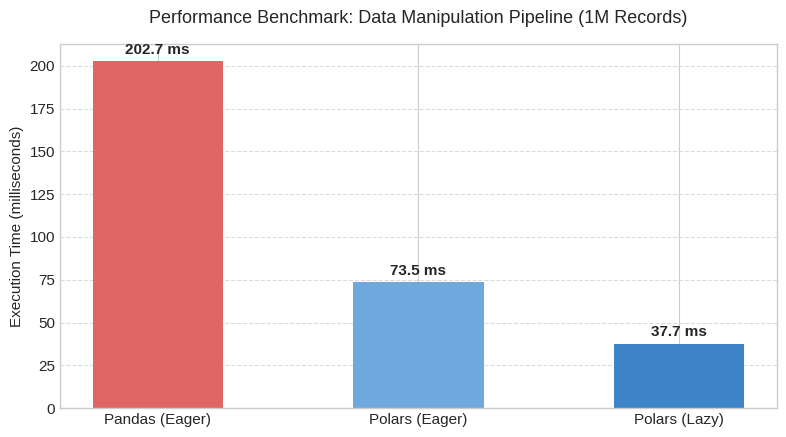

In [14]:
times_ms = [pd_time * 1000, pl_eager_time * 1000, pl_lazy_time * 1000]
labels = ["Pandas (Eager)", "Polars (Eager)", "Polars (Lazy)"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(labels, times_ms, color=["#e06666", "#6fa8dc", "#3d85c6"], width=0.5)

# Styling
ax.set_ylabel("Execution Time (milliseconds)")
ax.set_title("Performance Benchmark: Data Manipulation Pipeline (1M Records)", fontsize=13, pad=15)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} ms',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),  # 3 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

### Benchmark Analysis

- **Pandas vs. Polars (Eager)**: Polars typically shows a significant speedup (e.g. 5x to 10x) because operations are compiled into multi-threaded Rust executions instead of running single-threaded in Python.
- **Eager vs. Lazy Polars**: For in-memory DataFrames, Polars Lazy optimizes the execution tree, avoiding intermediate copies and running filters and calculations inside a single loop where possible.

## 9. Guided Exercises

### Exercise 1: Build a Latency Categorizer

Define a function `categorize_latency(df: pl.DataFrame) -> pl.DataFrame` using Polars expressions. It should:
1. Add a column `latency_class` which is:
   - `"fast"` if `response_time_ms` <= 300
   - `"average"` if 300 < `response_time_ms` <= 600
   - `"slow"` if `response_time_ms` > 600
2. Group by `latency_class` and count the requests in each group.

In [15]:
def categorize_latency(df: pl.DataFrame) -> pl.DataFrame:
    # --- YOUR CODE HERE ---
    # Tip: Use pl.when().then().otherwise()
    res = df.with_columns(
        pl.when(pl.col("response_time_ms") <= 300).then(pl.lit("fast"))
        .when(pl.col("response_time_ms") <= 600).then(pl.lit("average"))
        .otherwise(pl.lit("slow"))
        .alias("latency_class")
    )
    return res.group_by("latency_class").len()

# Verify implementation
print(categorize_latency(df_pl))

shape: (3, 2)
┌───────────────┬───────┐
│ latency_class ┆ len   │
│ ---           ┆ ---   │
│ str           ┆ u32   │
╞═══════════════╪═══════╡
│ slow          ┆ 15618 │
│ average       ┆ 68500 │
│ fast          ┆ 15882 │
└───────────────┴───────┘


### Exercise 2: Combine Logs with Multi-key Joins

Suppose we have user region billing rules. Perform a join using Polars of the base prompt logs `df_pl` with the billing table below on the `user_region` column. What is the total estimated revenue generated from the US regions (`us-east` and `us-west`), assuming the cost of processing error prompts is $0?

In [16]:
billing_rules = {
    "user_region": ["us-east", "us-west", "eu-central", "ap-northeast"],
    "price_per_prompt_token": [0.000002, 0.0000025, 0.000003, 0.000004],
}
df_billing = pl.DataFrame(billing_rules)

# --- YOUR CODE HERE ---
# 1. Join df_pl with df_billing on user_region
# 2. Calculate prompt_revenue = tokens_prompt * price_per_prompt_token if has_error is False, else 0
# 3. Filter for us-east or us-west region
# 4. Sum prompt_revenue

df_revenue = (
    df_pl.join(df_billing, on="user_region", how="inner")
    .with_columns(
        pl.when(pl.col("has_error") == False)
        .then(pl.col("tokens_prompt") * pl.col("price_per_prompt_token"))
        .otherwise(0.0)
        .alias("prompt_revenue")
    )
    .filter(pl.col("user_region").is_in(["us-east", "us-west"]))
)

total_rev = df_revenue["prompt_revenue"].sum()
print(f"Total Revenue: ${total_rev:.4f}")

Total Revenue: $89.0731


## 10. Challenge Problems

### Challenge 1: LLM Training Text Preparation Pipeline (Lazy)

When preparing data for LLM fine-tuning, you must pre-process hundreds of thousands of conversational pairs. Build a Lazy Pipeline in Polars that processes raw data records containing user questions and model replies:

1. **Filter out** records where prompt text is empty or too short (< 10 characters).
2. **Normalize** text columns by trimming leading/trailing whitespace and converting text to lowercase.
3. **Compute token metrics**: Count approximate words (split by whitespace) for prompts and completions.
4. **Compute ratio**: Ratio of completion words to prompt words.
5. **Extract Top Categories**: Group by a metadata category field and return the mean ratio, total logs processed, and maximum prompt word counts.

Run `.explain()` to inspect the logical execution plan, collect results, and prove that your code does not compile intermediate variables outside Rust execution space.

In [17]:
raw_texts = {
    "prompt": [
        " What is reinforcement learning?  ", 
        "Write a Python quicksort. ", 
        "hi", # Too short
        "  Explain quantum computing simply. ",
        ""
    ],
    "completion": [
        "RL is training models through rewards.",
        "def quicksort(arr): return arr...",
        "Hello!",
        "Quantum computing uses qubits and superposition...",
        ""
    ],
    "category": ["theory", "coding", "chat", "theory", "chat"]
}

df_texts = pl.DataFrame(raw_texts)

# Implement your Lazy pipeline here
lazy_pipe = (
    df_texts.lazy()
    .filter(pl.col("prompt").str.strip_chars().str.len_chars() >= 10)
    .with_columns([
        pl.col("prompt").str.strip_chars().str.to_lowercase(),
        pl.col("completion").str.strip_chars().str.to_lowercase(),
    ])
    .with_columns([
        pl.col("prompt").str.split(" ").list.len().alias("prompt_words"),
        pl.col("completion").str.split(" ").list.len().alias("completion_words"),
    ])
    .with_columns((pl.col("completion_words") / pl.col("prompt_words")).alias("ratio"))
    .group_by("category")
    .agg([
        pl.col("ratio").mean().alias("mean_ratio"),
        pl.len().alias("count"),
        pl.col("prompt_words").max().alias("max_prompt_words")
    ])
)

print(lazy_pipe.explain())
print(lazy_pipe.collect())

AGGREGATE[maintain_order: false]
  [col("ratio").mean().alias("mean_ratio"), len().alias("count"), col("prompt_words").max().alias("max_prompt_words")] BY [col("category")]
  FROM
   WITH_COLUMNS:
   [[(col("completion_words")) / (col("prompt_words"))].alias("ratio")] 
     WITH_COLUMNS:
     [col("prompt").str.split([" "]).list.length().alias("prompt_words"), col("completion").str.split([" "]).list.length().alias("completion_words")] 
       WITH_COLUMNS:
       [col("prompt").str.strip_chars([null]).str.lowercase(), col("completion").str.strip_chars([null]).str.lowercase()] 
        FILTER [(col("prompt").str.strip_chars([null]).str.len_chars()) >= (10)]
        FROM
          DF ["prompt", "completion", "category"]; PROJECT["category", "prompt", "completion"] 3/3 COLUMNS
shape: (2, 4)
┌──────────┬────────────┬───────┬──────────────────┐
│ category ┆ mean_ratio ┆ count ┆ max_prompt_words │
│ ---      ┆ ---        ┆ ---   ┆ ---              │
│ str      ┆ f64        ┆ u32   ┆ u32     

### Challenge 2: Streaming Execution for Out-of-Core Datasets

One of Polars' most powerful features is **streaming evaluation**, which allows it to process datasets larger than memory. Research how to write a streaming query in Polars using `pl.scan_csv()` or `pl.scan_parquet()` with the `.collect(streaming=True)` parameter. Explain when this should be used and what types of operations (e.g. joins, aggregations) are supported in streaming execution mode.

In [18]:
# Write a brief code demonstration of scanning a CSV using streaming.
# Since we don't have a physical file on disk, we can write a tiny CSV locally first, then scan it.

csv_path = "scratch_dummy_logs.csv"
df_pl.write_csv(csv_path)

# Streaming scan query:
streaming_result = (
    pl.scan_csv(csv_path)
    .filter(pl.col("response_time_ms") < 400)
    .group_by("model_name")
    .agg(pl.col("tokens_prompt").mean())
    .collect(streaming=True) # Enables streaming
)

print(streaming_result)

# Clean up file
import os
if os.path.exists(csv_path):
    os.remove(csv_path)

shape: (4, 2)
┌──────────────────┬───────────────┐
│ model_name       ┆ tokens_prompt │
│ ---              ┆ ---           │
│ str              ┆ f64           │
╞══════════════════╪═══════════════╡
│ phi-4            ┆ 1010.116781   │
│ llama-3-8b       ┆ 1015.254949   │
│ gemini-1.5-flash ┆ 992.593842    │
│ gpt-4o-mini      ┆ 1009.285247   │
└──────────────────┴───────────────┘


/tmp/ipykernel_9121/739852519.py:13: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  .collect(streaming=True) # Enables streaming


**Streaming Analysis**:
- **When to use**: When your dataset is larger than your physical RAM size (out-of-core data processing).
- **How it works**: Polars divides the input file into smaller batches, pipes them through the logical operations in parallel, and flushes intermediate results to disk if necessary.
- **Limitations**: Not all operations are fully streamable. Sorting and certain complex window functions can require global state and might temporarily fall back to in-memory processing.

## 11. Further Reading

- **Polars User Guide**: [https://docs.pola.rs/](https://docs.pola.rs/) - Official comprehensive documentation.
- **Apache Arrow Specifications**: [https://arrow.apache.org/](https://arrow.apache.org/) - Deep dive into memory layouts.
- **Pandas to Polars Migration Guide**: Key syntactical mappings for translating legacy code bases to high performance expressions.

---

**[← Previous: 05 — NumPy](05-numpy-essentials.ipynb)** · **[Next: 07 — Git & Dev Tools →](07-git-and-dev-tools.ipynb)**